In [ ]:
import yfinance as yf
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

In [ ]:
stock_data = yf.download("NFLX", start="2025-01-01", end= "2025-12-31")

/tmp/ipython-input-1511981826.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  stock_data = yf.download("NFLX", start="2025-01-01", end= "2025-12-31")
[*********************100%***********************]  1 of 1 completed


In [ ]:
stock_data.head(20)

Price,Close,High,Low,Open,Volume
Ticker,NFLX,NFLX,NFLX,NFLX,NFLX
Date,,,,,
2025-01-02,88.672997,89.858002,87.699997,89.550003,23123000
2025-01-03,88.105003,89.883003,87.988998,89.313004,29673000
2025-01-06,88.179001,89.282997,87.168999,88.875999,34577000
2025-01-07,87.918999,88.800003,86.911003,87.938004,26498000
2025-01-08,87.500000,88.622002,87.300003,88.000000,23479000
2025-01-10,83.768997,86.640999,83.440002,86.639999,48033000
2025-01-13,84.028999,84.707001,82.914001,83.153000,30245000
2025-01-14,82.839996,84.488998,82.351997,84.320000,30377000


In [ ]:
stock_data.index = pd.to_datetime(stock_data.index)
# Group by month and get the last closing price of each month
monthly_data = stock_data['Close'].resample('M').last()


/tmp/ipython-input-427277415.py:3: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_data = stock_data['Close'].resample('M').last()


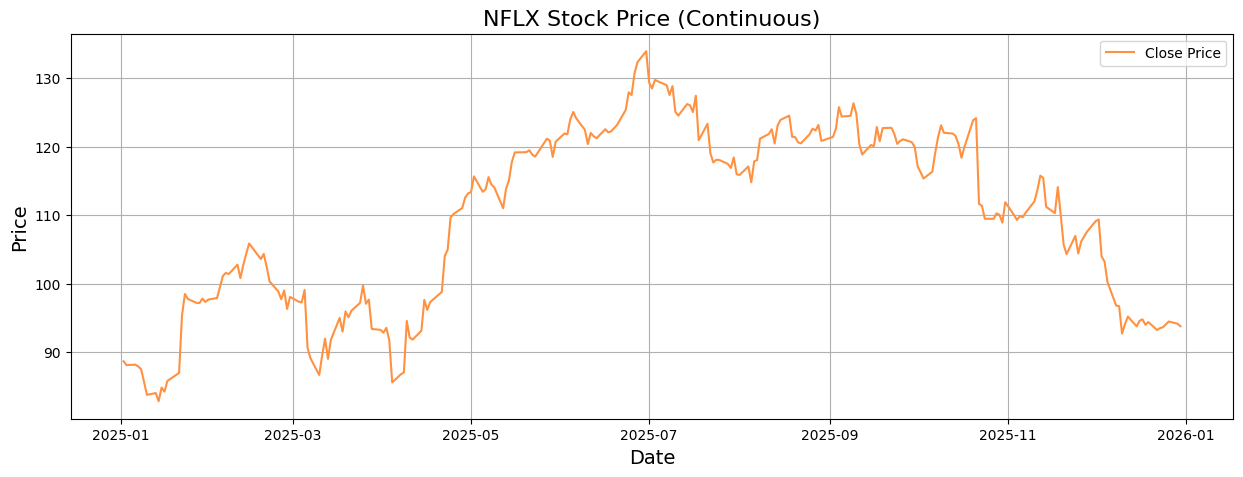

In [ ]:
plt.figure(figsize=(15,5))
plt.plot(stock_data.index, stock_data['Close'], color='#FF9140', label='Close Price')
plt.title('NFLX Stock Price (Continuous)', fontsize=16)
plt.xlabel('Date', fontsize=14)
plt.ylabel('Price', fontsize=14)
plt.legend()
plt.grid(True)
plt.show()

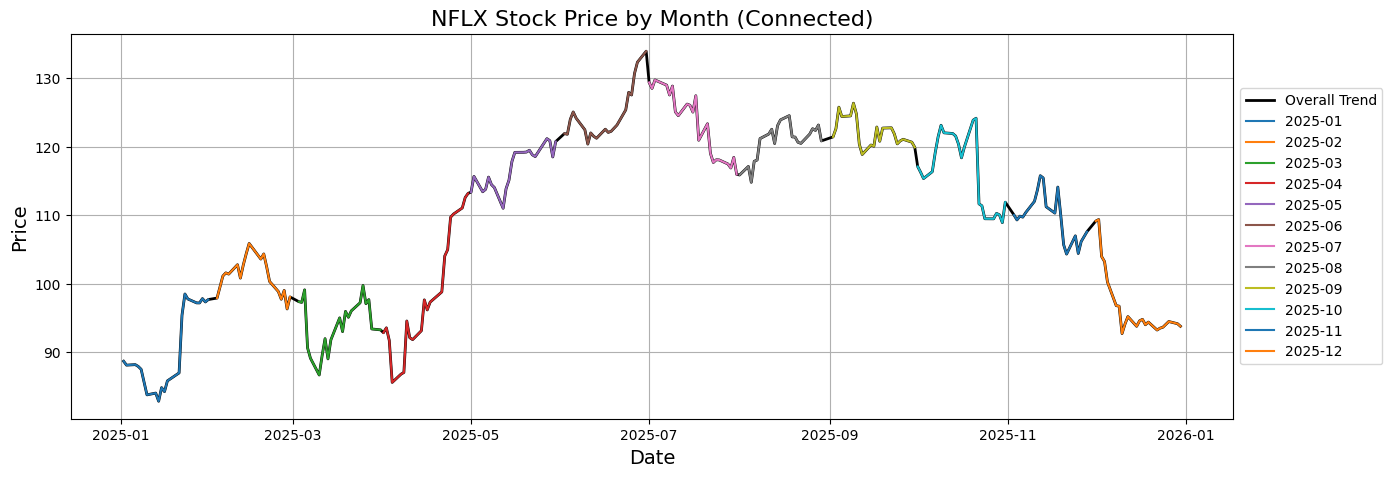

In [ ]:
plt.figure(figsize=(15,5))

# Plot the continuous line first
plt.plot(stock_data.index, stock_data['Close'], color='black', linewidth=2, label='Overall Trend')

# Overlay each month in different colors
for month, data in stock_data.groupby(stock_data.index.to_period('M')):
    plt.plot(data.index, data['Close'], label=str(month))

plt.title('NFLX Stock Price by Month (Connected)', fontsize=16)
plt.xlabel('Date', fontsize=14)
plt.ylabel('Price', fontsize=14)
plt.legend(loc='center left', bbox_to_anchor=(1.0, 0.5))
plt.grid(True)
plt.show()


Time series Decomposition

In [ ]:
# checking the additive component, if present
from statsmodels.tsa.seasonal import seasonal_decompose

decomposition_additive = seasonal_decompose(stock_data['Close'], model='additive', period=30)

trend_additive = decomposition_additive.trend
seasonal_additive = decomposition_additive.seasonal
residual_additive = decomposition_additive.resid

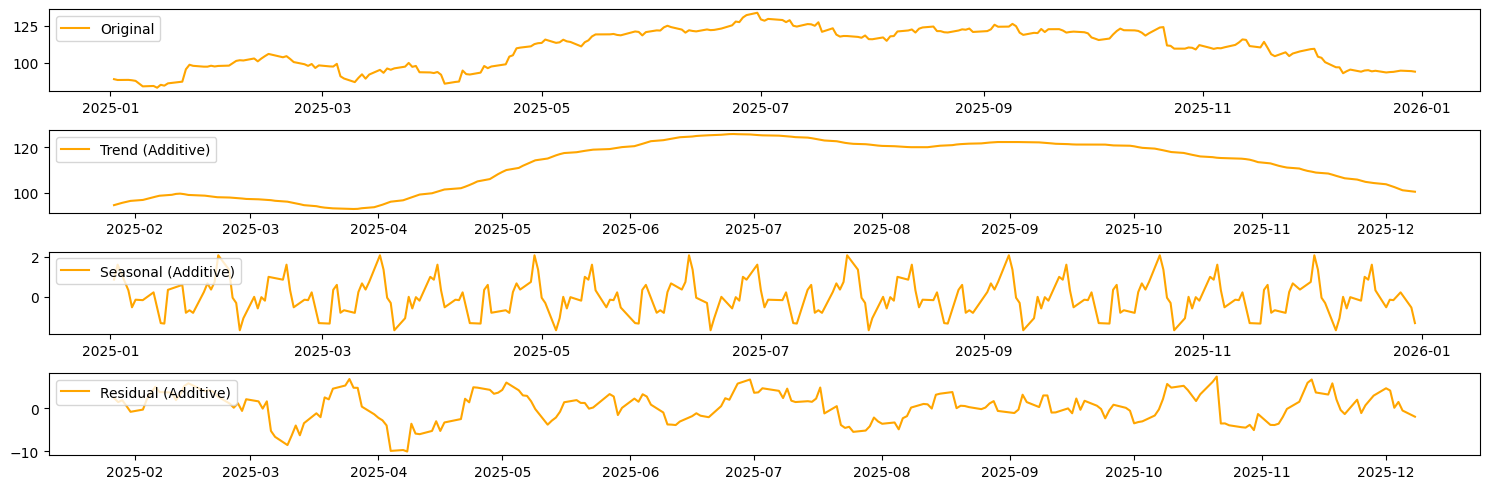

In [ ]:
plt.figure(figsize=(15,5))
plt.subplot(411)
plt.plot(stock_data['Close'], label='Original', color = 'orange')
plt.legend(loc='upper left')
plt.subplot(412)
plt.plot(trend_additive, label='Trend (Additive)', color = 'orange')
plt.legend(loc='upper left')
plt.subplot(413)
plt.plot(seasonal_additive, label='Seasonal (Additive)', color = 'orange')
plt.legend(loc='upper left')
plt.subplot(414)
plt.plot(residual_additive, label='Residual (Additive)', color = 'orange')
plt.legend(loc='upper left')
plt.tight_layout()

In [ ]:
decomposition_multiplicative = seasonal_decompose(stock_data['Close'], model='multiplicative', period=30)
trend_multiplicative = decomposition_multiplicative.trend
seasonal_multiplicative = decomposition_multiplicative.seasonal
residual_multiplicative = decomposition_multiplicative.resid

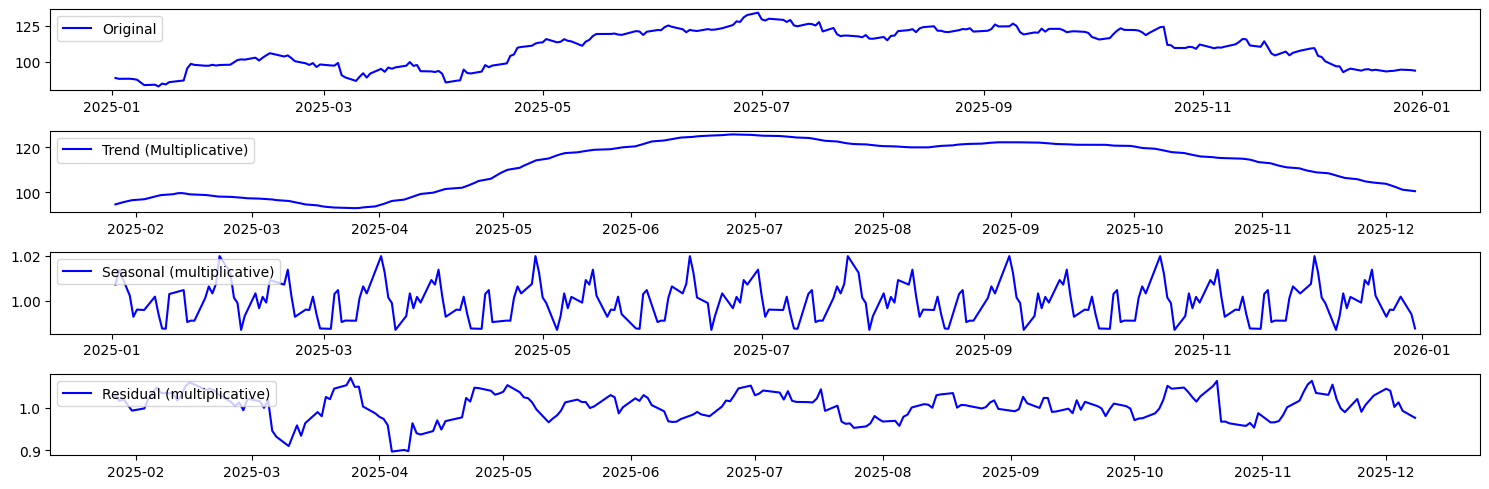

In [ ]:
plt.figure(figsize=(15,5))
plt.subplot(411)
plt.plot(stock_data['Close'], label='Original', color = 'blue')
plt.legend(loc='upper left')
plt.subplot(412)
plt.plot(trend_multiplicative, label='Trend (Multiplicative)', color = 'blue')
plt.legend(loc='upper left')
plt.subplot(413)
plt.plot(seasonal_multiplicative, label='Seasonal (multiplicative)', color = 'blue')
plt.legend(loc='upper left')
plt.subplot(414)
plt.plot(residual_multiplicative, label='Residual (multiplicative)', color = 'blue')
plt.legend(loc='upper left')
plt.tight_layout()



*   In the additive decomposition, the seasonal component looks like a flatrepeating wave (same height every year)
*  In the multiplicative decomposition, the seasonal component grows taller as the trend rises — the peaks and troughs get bigger because they’re percentages of the trend.


data’s seasonality is essentially additive in nature, which is why both decompositions show the same repeating pattern. Multiplicative decomposition doesn’t add new insight unless the seasonal variation grows or shrinks in proportion to the trend.


**Therefore datas shows additive decomposition**

**STL decomposition (Seasonal-Trend decomposition using LOESS) is a flexible method that breaks a time series into three parts: trend, seasonality, and residuals, using a smoothing technique called LOESS. Unlike classical additive or multiplicative decomposition, STL can handle complex seasonal patterns, irregular data, and allows you to control how smooth each component should be.**

In [ ]:
from statsmodels.tsa.seasonal import STL

stl = STL(stock_data['Close'], period=30)
result = stl.fit()

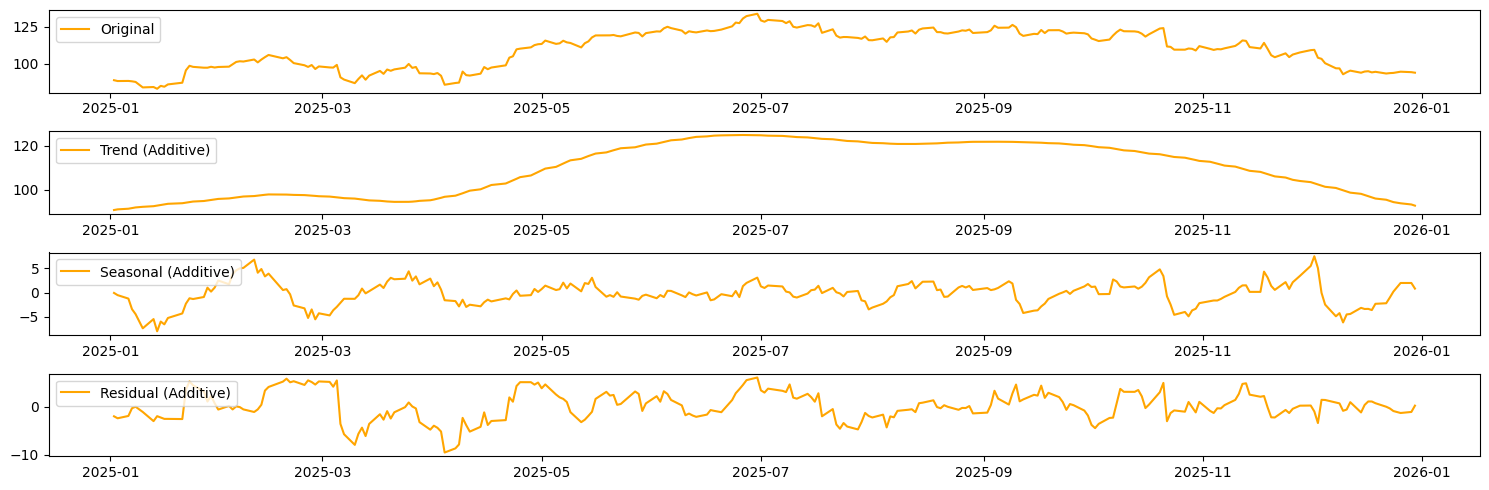

In [ ]:
plt.figure(figsize=(15,5))
plt.subplot(411)
plt.plot(result.observed, label='Original', color = 'orange')
plt.legend(loc='upper left')
plt.subplot(412)
plt.plot(result.trend, label='Trend (Additive)', color = 'orange')
plt.legend(loc='upper left')
plt.subplot(413)
plt.plot(result.seasonal, label='Seasonal (Additive)', color = 'orange')
plt.legend(loc='upper left')
plt.subplot(414)
plt.plot(result.resid, label='Residual (Additive)', color = 'orange')
plt.legend(loc='upper left')
plt.tight_layout()

**Stationarity**

**check for stationarity with ADF Test**

In [ ]:
from statsmodels.tsa.stattools import adfuller


adf_test = adfuller(stock_data['Close'])
print('ADF Test results')
print(f'ADF Statistic: {round(adf_test[0],3)}')
print(f'p-value: {round(adf_test[1],3)}')
print('critical_values')
for key, value in adf_test[4].items():
    print(f'{key}: {round(value,3)}')

ADF Test results
ADF Statistic: -1.591
p-value: 0.488
critical_values
1%: -3.457
5%: -2.873
10%: -2.573


**since P value more than 0.05 therefore fail to reject null hypothesis, that means Data is Non Stationary**

**Checking Stationarity with KPSS Test**

In [ ]:
from statsmodels.tsa.stattools import kpss

kpss_test = kpss(stock_data['Close'], regression = 'ct')

print('KPSS Test results')
print(f'KPSS Statistic: {round(kpss_test[0],3)}')
print(f'p-value: {round(kpss_test[1],3)}')
print('critical_values')

for key, value in kpss_test[3].items():
    print(f'{key}: {round(value,3)}')

KPSS Test results
KPSS Statistic: 0.473
p-value: 0.01
critical_values
10%: 0.119
5%: 0.146
2.5%: 0.176
1%: 0.216


/tmp/ipython-input-2299687585.py:3: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_test = kpss(stock_data['Close'], regression = 'ct')


**since p value is less than 0.05, reject null hypothesis, means data is non stationary**

**converting Non - Stationary time series into stationary**

In [ ]:
def adf_test(series):
  result = adfuller(series)
  print('ADF Test Results')
  print(  f'ADF Statistic: {round(result[0],3)}')
  print(  f'p-value: {round(result[1],3)}')
  print(f'Critical Values:')
  for key, value in result[4].items():
    print(f'key: {key}, value: {round(value,3)}')


def kpss_test(series):
  result = kpss(series, regression = 'c')
  print('KPSS Test results')
  print(f'KPSS Statistic: {round(kpss_test[0],3)}')
  print(f'p-value: {round(kpss_test[1],3)}')
  print('critical_values')

  for key, value in kpss_test[3].items():
      print(f'{key}: {round(value,3)}')

In [ ]:
prices = stock_data['Close']

Making a ADF test function


In [ ]:
from statsmodels.tsa.stattools import adfuller

def adf_test(series):
  result = adfuller(series)
  print('ADF Test Results')
  print(  f'ADF Statistic: {round(result[0],3)}')
  print(  f'p-value: {round(result[1],3)}')
  print(f'Critical Values:')
  for key, value in result[4].items():
    print(f'key: {key}, value: {round(value,3)}')

adf_test(prices)

ADF Test Results
ADF Statistic: -1.591
p-value: 0.488
Critical Values:
key: 1%, value: -3.457
key: 5%, value: -2.873
key: 10%, value: -2.573


In [ ]:
prices

Ticker,NFLX
Date,
2025-01-02,88.672997
2025-01-03,88.105003
2025-01-06,88.179001
2025-01-07,87.918999
2025-01-08,87.500000
...,...
2025-12-23,93.500000
2025-12-24,93.639999
2025-12-26,94.470001


**1.   Differencing**

In [ ]:
#First Order Differencing
first_order_prices = prices.diff()
first_order_prices

Ticker,NFLX
Date,
2025-01-02,NaN
2025-01-03,-0.567993
2025-01-06,0.073997
2025-01-07,-0.260002
2025-01-08,-0.418999
...,...
2025-12-23,0.269997
2025-12-24,0.139999
2025-12-26,0.830002


In [ ]:
#second order differencing
second_order_prices = prices.diff().diff()
second_order_prices

Ticker,NFLX
Date,
2025-01-02,NaN
2025-01-03,NaN
2025-01-06,0.641991
2025-01-07,-0.334000
2025-01-08,-0.158997
...,...
2025-12-23,1.429993
2025-12-24,-0.129997
2025-12-26,0.690002


**2. Transformation**

In [ ]:
from scipy import stats


#log transformation
log_prices = np.log(prices)

#Square root transformation
sqrt_prices = np.sqrt(prices)

#Box-Cox transformation
box_cox_prices = stats.boxcox(prices['NFLX'][prices['NFLX'] > 0])

In [ ]:
print(f'Log Prices: {log_prices}')
#print(sqrt_prices)
#print(box_cox_prices)

Log Prices: Ticker          NFLX
Date                
2025-01-02  4.484955
2025-01-03  4.478529
2025-01-06  4.479369
2025-01-07  4.476416
2025-01-08  4.471639
...              ...
2025-12-23  4.537961
2025-12-24  4.539458
2025-12-26  4.548282
2025-12-29  4.544889
2025-12-30  4.540952

[249 rows x 1 columns]


In [ ]:
print(f'Sqrt Prices: {sqrt_prices}')

Sqrt Prices: Ticker          NFLX
Date                
2025-01-02  9.416634
2025-01-03  9.386427
2025-01-06  9.390367
2025-01-07  9.376513
2025-01-08  9.354143
...              ...
2025-12-23  9.669540
2025-12-24  9.676776
2025-12-26  9.719568
2025-12-29  9.703092
2025-12-30  9.684007

[249 rows x 1 columns]


In [ ]:
print(f'box cox Prices: {box_cox_prices}')

box cox Prices: (array([27480.74761802, 27045.96984675, 27102.37776114, 26904.48919306,
       26587.40782392, 23862.18768701, 24046.41479559, 23210.83182972,
       24616.41512012, 24194.40484579, 25331.1848267 , 26188.04285675,
       32947.97729177, 35657.61909633, 35007.96635112, 34503.58867391,
       34498.29884632, 35057.75495072, 34622.64691164, 34934.24974543,
       35128.05992032, 36563.81926706, 38063.0022404 , 38491.37646231,
       38326.99739288, 39622.21051313, 37780.55751148, 39594.46705904,
       41179.75700488, 42655.19283598, 40416.34571387, 41144.51262088,
       39330.04712894, 37323.68935466, 35982.86574851, 34976.8665389 ,
       36126.67493584, 33731.72318862, 35272.50461804, 34663.27713563,
       34564.41276181, 36204.60853548, 29015.36088577, 27818.8538136 ,
       25964.42339164, 28129.00468506, 30085.14446042, 27746.08335063,
       29948.94199311, 32608.75178806, 30928.27952313, 33421.39701975,
       32678.64686148, 33490.59635402, 34512.39492459, 36784

In [ ]:
adf_test(log_prices)

ADF Test Results
ADF Statistic: -1.645
p-value: 0.46
Critical Values:
key: 1%, value: -3.457
key: 5%, value: -2.873
key: 10%, value: -2.573


Since p value is not less than 0.05, fails to reject null hypothesis, therefore Non- stationary data series

In [ ]:
adf_test(sqrt_prices)

ADF Test Results
ADF Statistic: -1.615
p-value: 0.476
Critical Values:
key: 1%, value: -3.457
key: 5%, value: -2.873
key: 10%, value: -2.573


In [ ]:
adf_test(box_cox_prices[0])

ADF Test Results
ADF Statistic: -1.562
p-value: 0.503
Critical Values:
key: 1%, value: -3.457
key: 5%, value: -2.873
key: 10%, value: -2.573


**First-order differencing:**
- ADF statistic = -15.965, which is far below all critical values.
- p-value = 0.0, meaning we strongly reject the null hypothesis of a unit root.

**Conclusion: The first-order differenced series is stationary**


In [ ]:
adf_test(first_order_prices.dropna())

ADF Test Results
ADF Statistic: -15.965
p-value: 0.0
Critical Values:
key: 1%, value: -3.457
key: 5%, value: -2.873
key: 10%, value: -2.573


**Second-order differencing:**
- ADF statistic = -7.438, also well below critical values.
- p-value = 0.0, again rejecting the null hypothesis.

**Conclusion: The second-order differenced series is stationary too**


In [ ]:
adf_test(second_order_prices.dropna())

ADF Test Results
ADF Statistic: -7.438
p-value: 0.0
Critical Values:
key: 1%, value: -3.459
key: 5%, value: -2.874
key: 10%, value: -2.573


**3. Using Detrending**

In [ ]:
from scipy.signal import detrend
detrended_prices = detrend(prices)

In [ ]:
from scipy import signal

# 1.  using Linear Trend
trend = np.polyfit(np.arange(len(prices)), prices['NFLX'], 1)
trend_line = np.polyval(trend, np.arange(len(prices)))
detrended_prices = prices['NFLX'] - trend_line

In [ ]:
adf_test(detrended_prices)

ADF Test Results
ADF Statistic: -0.949
p-value: 0.771
Critical Values:
key: 1%, value: -3.457
key: 5%, value: -2.873
key: 10%, value: -2.573


- The ADF statistic is -0.949, which is much higher (closer to zero) than the critical values at 1%, 5%, and 10% significance levels (all around -2.5 to -3.5).
- The p-value is 0.771, which is far greater than typical thresholds (0.05 or 0.01).
- In the Augmented Dickey-Fuller (ADF) test, the null hypothesis is that the series has a unit root (i.e., it is non-stationary). Since the p-value is so high, we fail to reject the null hypothesis.

**Conclusion: Even after detrending, the Netflix price series still shows non-stationarity.**


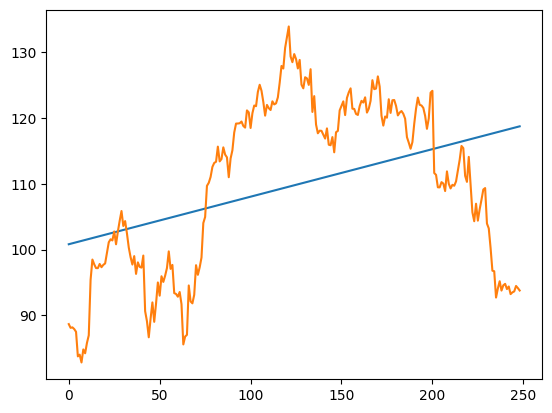

In [ ]:
plt.plot(np.arange(len(prices)), trend_line)
plt.plot(np.arange(len(prices)), prices)
plt.show()

In [ ]:
# 2. using moving average
window = 12
price_mov_avg = prices['NFLX'].rolling(window=window).mean()
(detrended_prices) = ((prices['NFLX'] - price_mov_avg).dropna())

In [ ]:
adf_test(detrended_prices)

ADF Test Results
ADF Statistic: -3.994
p-value: 0.001
Critical Values:
key: 1%, value: -3.458
key: 5%, value: -2.874
key: 10%, value: -2.573


The ADF statistic is -3.994, which is lower (more negative) than all the critical values at 1%, 5%, and 10% levels.
- The p-value is 0.001, which is far below 0.05.
- That means we can reject the null hypothesis of a unit root and conclude the series is stationary after detrending with a moving average.

 So unlike the earlier linear detrending attempt (which left the series non-stationary), **the moving average detrending successfully produced a stationary series**.


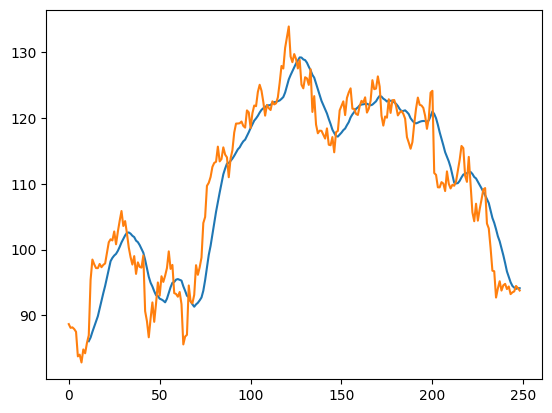

In [ ]:
plt.plot(np.arange(len(prices)), price_mov_avg)
plt.plot(np.arange(len(prices)), prices)
plt.show()

**4. Seasonal Adjustment**

In [ ]:
decompose = seasonal_decompose(prices['NFLX'], model='additive', period=30)
price_adjusted = (prices['NFLX'] - decompose.seasonal).dropna()


In [ ]:
adf_test(price_adjusted)

ADF Test Results
ADF Statistic: -1.634
p-value: 0.466
Critical Values:
key: 1%, value: -3.457
key: 5%, value: -2.873
key: 10%, value: -2.573


**Conclusion**

Even after seasonal adjustment (removing the seasonal component), the Netflix price series remains non-stationary. This suggests that seasonality alone wasn’t the main source of non-stationarity, the series likely still has a trend or unit root.


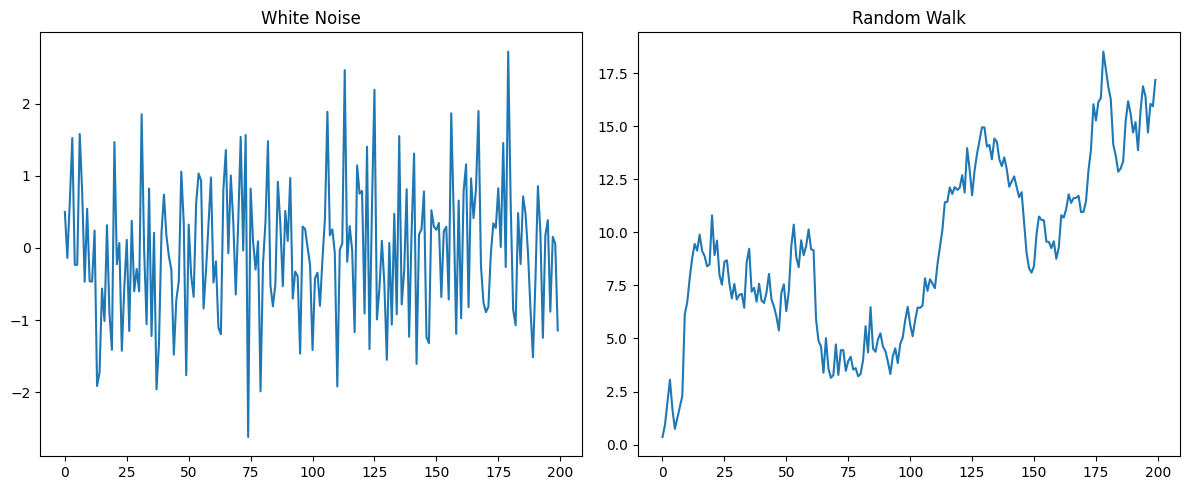

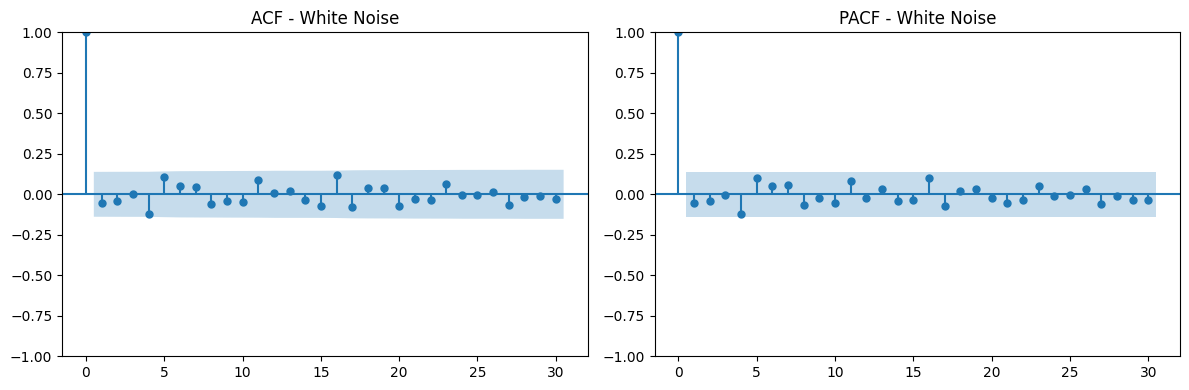

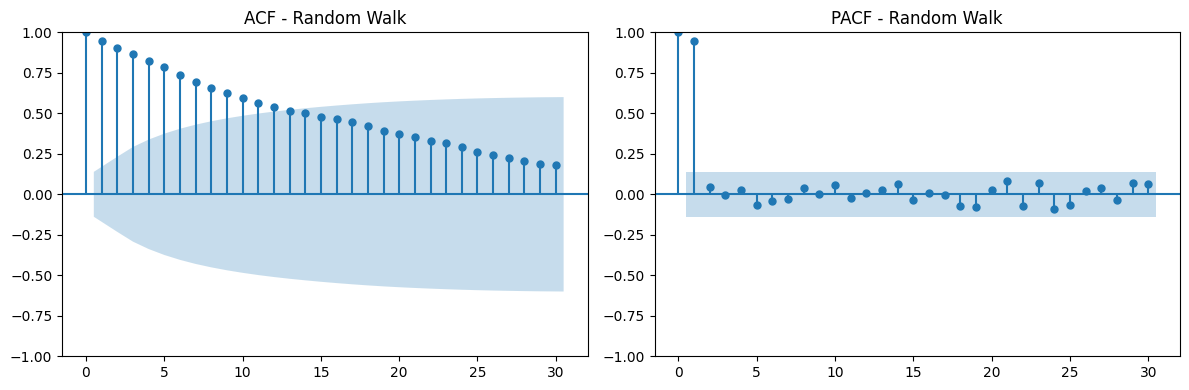


Ljung-Box Test for White Noise
     lb_stat  lb_pvalue
10  8.849179   0.546474

Ljung-Box Test for Random Walk
        lb_stat      lb_pvalue
10  1235.017347  4.023180e-259

ADF Test for White Noise
ADF Statistic: -14.74419994660189
p-value: 2.543125112212854e-27
Critical Value (1%): -3.4636447617687436
Critical Value (5%): -2.8761761179270766
Critical Value (10%): -2.57457158581854

ADF Test for Random Walk
ADF Statistic: -1.8198097716075297
p-value: 0.3706719846672205
Critical Value (1%): -3.4636447617687436
Critical Value (5%): -2.8761761179270766
Critical Value (10%): -2.57457158581854


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller, acf, pacf
from statsmodels.stats.diagnostic import acorr_ljungbox

# 1. Generate random series
np.random.seed(42)
n = 200

# White noise
white_noise = np.random.normal(loc=0, scale=1, size=n)

# Random walk
random_walk = np.cumsum(np.random.normal(loc=0, scale=1, size=n))

# 2. Plot both series
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(white_noise)
plt.title("White Noise")
plt.subplot(1, 2, 2)
plt.plot(random_walk)
plt.title("Random Walk")
plt.tight_layout()
plt.show()

# 3. ACF and PACF plots
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

def plot_acf_pacf(series, title):
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plot_acf(series, ax=plt.gca(), lags=30)
    plt.title(f"ACF - {title}")
    plt.subplot(1, 2, 2)
    plot_pacf(series, ax=plt.gca(), lags=30)
    plt.title(f"PACF - {title}")
    plt.tight_layout()
    plt.show()

plot_acf_pacf(white_noise, "White Noise")
plot_acf_pacf(random_walk, "Random Walk")

# 4. Ljung-Box test
def ljung_box_test(series, name):
    lb_test = acorr_ljungbox(series, lags=[10], return_df=True)
    print(f"\nLjung-Box Test for {name}")
    print(lb_test)

ljung_box_test(white_noise, "White Noise")
ljung_box_test(random_walk, "Random Walk")

# 5. ADF test
def adf_test(series, name):
    result = adfuller(series)
    print(f"\nADF Test for {name}")
    print(f"ADF Statistic: {result[0]}")
    print(f"p-value: {result[1]}")
    for key, value in result[4].items():
        print(f"Critical Value ({key}): {value}")

adf_test(white_noise, "White Noise")
adf_test(random_walk, "Random Walk")



**AR Model**

In [ ]:
import yfinance as yf
stock_data = yf.download("NFLX", start="2025-01-01", end= "2025-12-31")

# making series stationary
stock_data_stationary = stock_data['Close'].diff().dropna()

/tmp/ipython-input-111635123.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  stock_data = yf.download("NFLX", start="2025-01-01", end= "2025-12-31")
[*********************100%***********************]  1 of 1 completed


**Split data into Test and Train dataset**

In [ ]:
train_size = int(len(stock_data_stationary)* 0.70)

train_data = stock_data_stationary[0:train_size]
test_data = stock_data_stationary[train_size:]


In [ ]:
from statsmodels.tsa.ar_model import AutoReg
from sklearn.metrics import mean_squared_error
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')


In [ ]:
# Fit AR model on training data

model = AutoReg(train_data, lags=30)  # lag 30, we want to predict 30 day data based on last 30 day data
model_fit = model.fit()


In [ ]:
#  Make predictions on test data


predictions = model_fit.predict(
    start=len(train_data),
    end=len(train_data) + len(test_data) - 1,
    dynamic=False
)


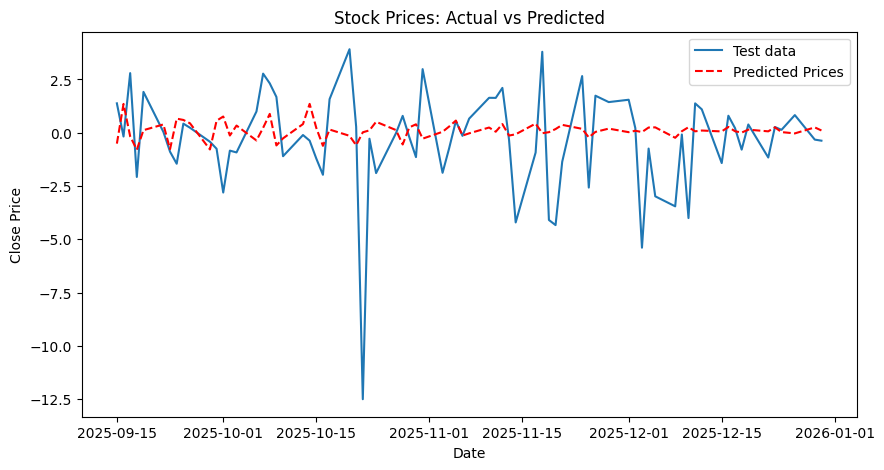

RMSE: 2.43


In [ ]:
 # Plot actual vs predicted
# -----------------------------
plt.figure(figsize=[10, 5])
plt.plot(test_data.index, test_data, label='Test data')
plt.plot(test_data.index, predictions, color='red', linestyle='--', label='Predicted Prices')
plt.title('Stock Prices: Actual vs Predicted')
plt.xlabel('Date')
plt.ylabel('Close Price')
plt.legend()
plt.show()

# -----------------------------
# Evaluate model performance
# -----------------------------
rmse = round(np.sqrt(mean_squared_error(test_data, predictions)), 2)
print('RMSE:', rmse)


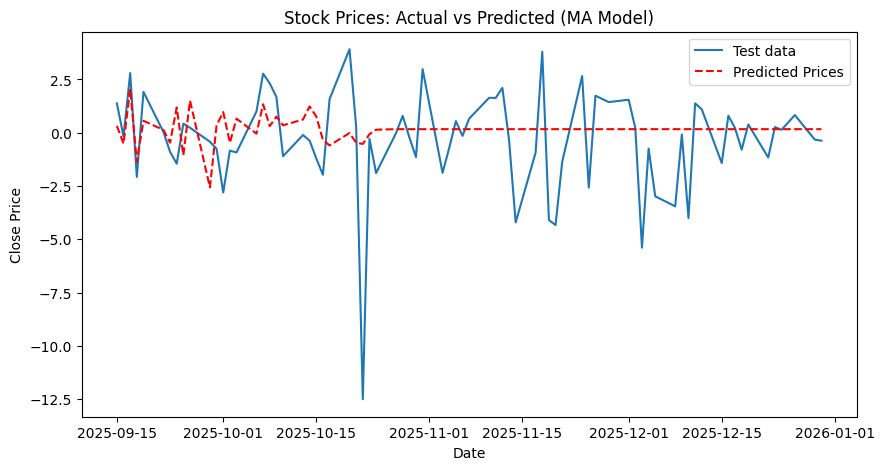

In [ ]:
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA


# 1. Fit the Moving Average (MA) model
# order=(p,d,q) → here p=0 (no AR), d=0 (no differencing), q=30 (MA terms)
model = ARIMA(train_data, order=(0, 0, 30))
model_fit = model.fit()


# 2. Make predictions on the test data
predictions = model_fit.predict(
    start=len(train_data),
    end=len(train_data) + len(test_data) - 1,
    dynamic=False
)


# 3. Plot actual vs predicted values
plt.figure(figsize=(10, 5))
plt.plot(test_data.index, test_data, label='Test data')
plt.plot(test_data.index, predictions, color='red', linestyle='--', label='Predicted Prices')
plt.title('Stock Prices: Actual vs Predicted (MA Model)')
plt.xlabel('Date')
plt.ylabel('Close Price')
plt.legend()
plt.show()


AR(100) AIC: 696.0249853533671
AR(101) AIC: 676.8451193467844
AR(102) AIC: 668.2127791049182
AR(103) AIC: 654.2778301309506
AR(104) AIC: 648.3377986652798
AR(105) AIC: 640.2077318768
AR(106) AIC: 636.2271865726075
AR(107) AIC: 631.5549289087662
AR(108) AIC: 620.3721335441646
AR(109) AIC: 602.7847482012254


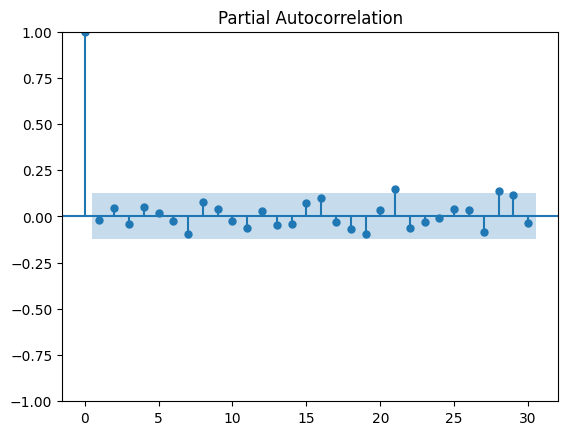

In [ ]:
from statsmodels.graphics.tsaplots import plot_pacf
from statsmodels.tsa.ar_model import AutoReg

# Plot PACF to visually decide lag
plot_pacf(stock_data_stationary, lags=30)

# Fit AR models with different lags and compare AIC
# The number of lags (p) must be less than the number of observations (nobs).
# stock_data_stationary has 248 observations, so p must be < 248.
# Let's check a more reasonable range for lags, for example, up to 30 as plotted in PACF.
for p in range(100, 110):
    try:
        model = AutoReg(stock_data_stationary, lags=p).fit()
        print(f"AR({p}) AIC: {model.aic}")
    except Exception as e:
        print(f"Could not fit AR({p}) model: {e}")

**To find best lag**

In [ ]:
from statsmodels.tsa.ar_model import AutoReg
import pandas as pd


# 1. Define maximum lag to test
max_lag = 30

results = []


# 2. Fit AR models with different lags
for p in range(1, max_lag+1):
    try:
        model = AutoReg(stock_data_stationary, lags=p).fit()
        results.append((p, model.aic, model.bic))
    except Exception as e:
        print(f"AR({p}) failed: {e}")


# 3. Collect results into DataFrame
df_results = pd.DataFrame(results, columns=["Lag (p)", "AIC", "BIC"])


# 4. Find best lag by AIC/BIC
best_aic = df_results.loc[df_results["AIC"].idxmin()]
best_bic = df_results.loc[df_results["BIC"].idxmin()]

print("Best lag by AIC:", best_aic)
print("Best lag by BIC:", best_bic)


# 5. results
print(df_results)


Best lag by AIC: Lag (p)      30.000000
AIC        1010.804213
BIC        1119.108055
Name: 29, dtype: float64
Best lag by BIC: Lag (p)      29.000000
AIC        1012.799205
BIC        1117.860428
Name: 28, dtype: float64
    Lag (p)          AIC          BIC
0         1  1112.592272  1123.120437
1         2  1110.555483  1124.576809
2         3  1108.697912  1126.204203
3         4  1106.473135  1127.456145
4         5  1102.217182  1126.668612
5         6  1100.593672  1128.505174
6         7  1096.774902  1128.138075
7         8  1093.156338  1127.962727
8         9  1091.316339  1129.557438
9        10  1089.256116  1130.923364
10       11  1086.494631  1131.579413
11       12  1071.931917  1120.425562
12       13  1067.187343  1119.081126
13       14  1065.166172  1120.451310
14       15  1062.508035  1121.175688
15       16  1058.283969  1120.325242
16       17  1056.717192  1122.123128
17       18  1054.226700  1122.988286
18       19  1050.273022  1122.381184
19       20  1048.